In [50]:
import pandas as pd
import glob
import os
import re
import sys
from omegaconf import OmegaConf

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

data = pd.read_pickle('../sampling_test/validated_final_df.pkl')
data = data[~data['Ucell'].isna()]
parameter_ranges = OmegaConf.load('../param_config.yaml')

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process.kernels import RBF

X = np.array(data[parameter_ranges])
Y = np.array(data['Ucell'].tolist())

def train_GP(X, Y, test_size=0.2, random_state=42):
    # Split data
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    # Scale input features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define kernel
    kernel = RBF(length_scale=1.0)

    # Initialize GP
    gp = GaussianProcessRegressor(n_restarts_optimizer=10, kernel=kernel, normalize_y=True)
    multi_gp = MultiOutputRegressor(gp, n_jobs=-1)

    # Measure fitting time
    start_time = time.time()
    multi_gp.fit(X_train_scaled, Y_train)
    elapsed_time = time.time() - start_time

    print(f"Fitting time: {elapsed_time:.2f} seconds")

    # Predict
    Y_pred = []
    Y_std = []
    for estimator in multi_gp.estimators_:
        mu, std = estimator.predict(X_test_scaled, return_std=True)
        Y_pred.append(mu)
        Y_std.append(std)

    Y_pred = np.array(Y_pred).T
    Y_std = np.array(Y_std).T

    # Evaluation
    mse_per_point = np.mean((Y_pred - Y_test) ** 2, axis=0)
    avg_mse = np.mean(mse_per_point)
    print("Average MSE across all time points:", avg_mse)

    return multi_gp, Y_test, Y_pred, Y_std, elapsed_time

# Use test_size=0.2 → 80% training
multi_gp, Y_test, Y_pred, Y_std, elapsed_time = train_GP(X, Y, test_size=0.98, random_state=42)


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to

Fitting time: 6.68 seconds
Average MSE across all time points: 2.5074309348230592


In [3]:
from sklearn.metrics import r2_score

# Y_test and Y_pred are assumed to be NumPy arrays or pandas Series
r2 = r2_score(Y_test, Y_pred)
print(f"R² score: {r2:.4f}")

R² score: 0.0840


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
import numpy as np

# 0) assume X, Y, and train_GP are defined as before

# 1) Cluster on the Ucell outputs
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(Y)

# 2) Train a separate GP on each cluster and compute MSE + R2
cluster_results = {}

for cl in range(n_clusters):
    idx = np.where(cluster_labels == cl)[0]
    X_cl, Y_cl = X[idx], Y[idx]
    print(f"\n--- Cluster {cl}: {len(idx)} samples ---")

    # train_GP prints fit time + avg MSE internally, but we’ll recompute MSE/R2 here
    multi_gp_cl, Y_test_cl, Y_pred_cl, Y_std_cl, elapsed_time_cl = train_GP(
        X_cl, Y_cl,
        test_size=0.95,
        random_state=42
    )

    # compute per-output MSE & overall average
    mse_per_output = np.mean((Y_pred_cl - Y_test_cl) ** 2, axis=0)
    avg_mse = mse_per_output.mean()

    # compute R2 per output and overall mean
    r2_per_output = [
        r2_score(Y_test_cl[:, i], Y_pred_cl[:, i])
        for i in range(Y_test_cl.shape[1])
    ]
    avg_r2 = np.mean(r2_per_output)

    cluster_results[cl] = {
        'fit_time_sec': elapsed_time_cl,
        'avg_mse':      avg_mse,
        'avg_r2':       avg_r2,
        'mse_per_out':  mse_per_output,
        'r2_per_out':   r2_per_output
    }

# 3) Summarize
for cl, res in cluster_results.items():
    print(f"Cluster {cl}:")
    print(f"  Fit time = {res['fit_time_sec']:.2f}s")
    print(f"  Avg MSE  = {res['avg_mse']:.4f}")
    print(f"  Avg R²   = {res['avg_r2']:.4f}")



--- Cluster 0: 28398 samples ---


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Fitting time: 61.70 seconds
Average MSE across all time points: 0.49918042030051335

--- Cluster 1: 252 samples ---
Fitting time: 0.06 seconds
Average MSE across all time points: 30.923043751081124
Cluster 0:
  Fit time = 61.70s
  Avg MSE  = 0.4992
  Avg R²   = 0.0707
Cluster 1:
  Fit time = 0.06s
  Avg MSE  = 30.9230
  Avg R²   = 0.2487


# Random Forest

In [6]:
import time
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# prepare your data exactly as before
target_cols = [f"Ucell_{i}" for i in range(30)]
# Split features and targets
X = data.dropna()[parameter_ranges]
y = data.dropna()[target_cols]

def train_RF(
    X, Y,
    test_size=0.2,
    random_state=42,
    n_estimators=100,
    max_depth=None,
    n_jobs=-1
):
    # 1) Split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )
    # 2) Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # 3) Instantiate RF inside a multi‐output wrapper
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=n_jobs
    )
    multi_rf = MultiOutputRegressor(rf, n_jobs=n_jobs)

    # 4) Fit & time it
    start_time = time.time()
    multi_rf.fit(X_train_scaled, Y_train)
    elapsed_time = time.time() - start_time
    print(f"Fitting time: {elapsed_time:.2f} seconds")

    # 5) Predict mean
    Y_pred = multi_rf.predict(X_test_scaled)

    # 6) Estimate per‐sample std by looking at tree spreads
    Y_std = []
    for est in multi_rf.estimators_:
        # stack shape (n_trees, n_samples)
        all_tree_preds = np.stack([t.predict(X_test_scaled) for t in est.estimators_])
        Y_std.append(np.std(all_tree_preds, axis=0))
    Y_std = np.array(Y_std).T  # shape (n_samples, n_outputs)

    # 7) Compute MSE metrics
    mse_per_point = np.mean((Y_pred - Y_test)**2, axis=0)
    avg_mse = np.mean(mse_per_point)
    print("Average MSE across all time points:", avg_mse)

    return multi_rf, Y_test, Y_pred, Y_std, elapsed_time, X_test_scaled

# run it
multi_rf, Y_test, Y_pred, Y_std, elapsed_time, X_test_scaled = train_RF(X, y)
r2 = r2_score(Y_test, Y_pred)
print(f"R² score: {r2:.4f}")


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting time: 70.93 seconds
Average MSE across all time points: 0.5263907747064677
R² score: 0.7908


In [33]:
import time
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# === Prepare data ===
target_cols = [f"Ucell_{i}" for i in range(30)]
# Assume `all` is your DataFrame and `parameter_ranges` your feature list:
df = all.dropna(subset=target_cols + list(parameter_ranges))
X = df[parameter_ranges].values
# Sum across the 30 Ucell columns to get a single target
y = df[target_cols].values.sum(axis=1)

# === Train/Test split & scaling ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# === Fit single-output RF and time it ===
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
start = time.time()
rf.fit(X_train_scaled, y_train)
elapsed = time.time() - start
print(f"Fitting time: {elapsed:.2f} s")

# === Evaluate ===
y_pred = rf.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {r2:.4f}")


Fitting time: 1.72 s
R² score: 0.7987


        feature  mean_abs_shap
5           tau       9.517167
6    epsilon_mc       8.214343
0           Tfc       2.182321
10     i0_c_ref       1.717390
1        Pa_des       1.374475
3     Phi_c_des       1.156555
9            Re       0.947195
12      kappa_c       0.823532
2            Sc       0.680210
7     epsilon_c       0.661110
11     kappa_co       0.624151
4   epsilon_gdl       0.609391
8             e       0.192372


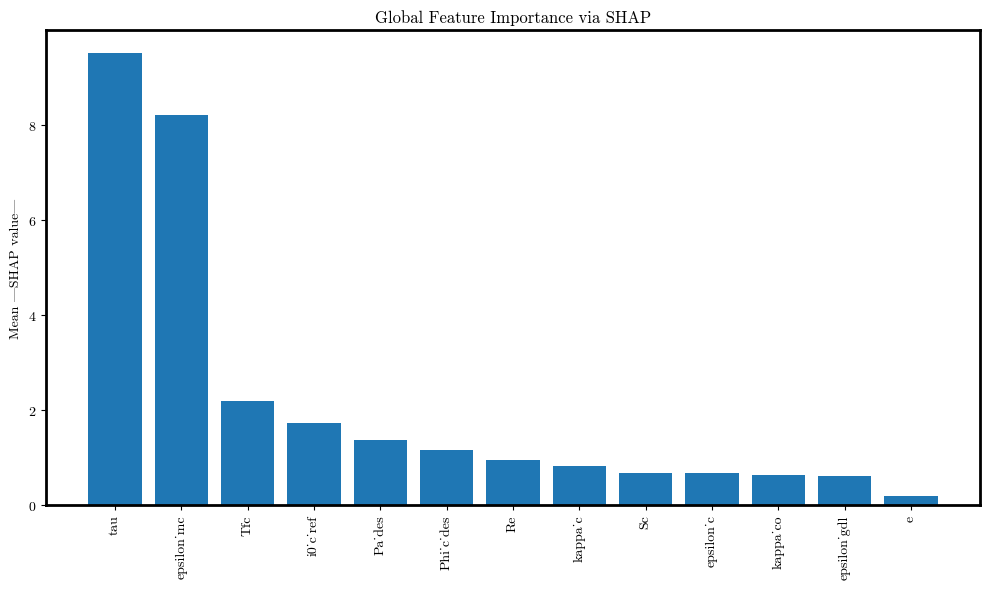

In [34]:
# 1) Install shap if you haven’t already:
#    pip install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2) Create a SHAP TreeExplainer for your RF
explainer = shap.TreeExplainer(rf)

# 3) Compute SHAP values on your train (or test) set
#    This returns an array of shape (n_samples, n_features)
shap_values = explainer.shap_values(X_test_scaled)

# 4) Aggregate to get global importance: mean absolute SHAP per feature
global_shap = np.mean(np.abs(shap_values), axis=0)

# 5) Build a DataFrame and sort descending
df_shap = pd.DataFrame({
    'feature': parameter_ranges,
    'mean_abs_shap': global_shap
}).sort_values('mean_abs_shap', ascending=False)

print(df_shap)

# 6) (Optional) Visualize as a bar chart
plt.figure(figsize=(10, 6))
plt.bar(df_shap['feature'], df_shap['mean_abs_shap'])
plt.xticks(rotation=90)
plt.ylabel('Mean |SHAP value|')
plt.title('Global Feature Importance via SHAP')
plt.tight_layout()
plt.show()


In [ ]:
# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer

df = data
df['Ucell'] = df[target_cols].apply(list, axis=1)
SA = SensitivityAnalyzer(parameter_ranges=parameter_ranges)
df['Ucell_regions'] = SA.aggregate_output_function(df, aggregation_method='sum', by_regions=True)


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1  R² = 0.7673


/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_57097/2245681541.py:53: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


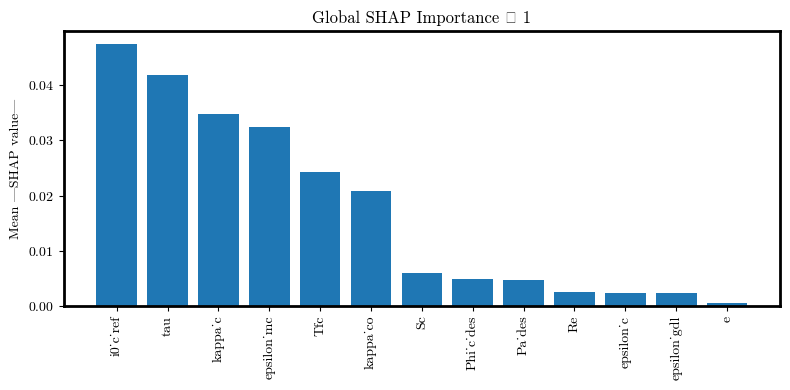

2  R² = 0.7659


/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_57097/2245681541.py:53: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


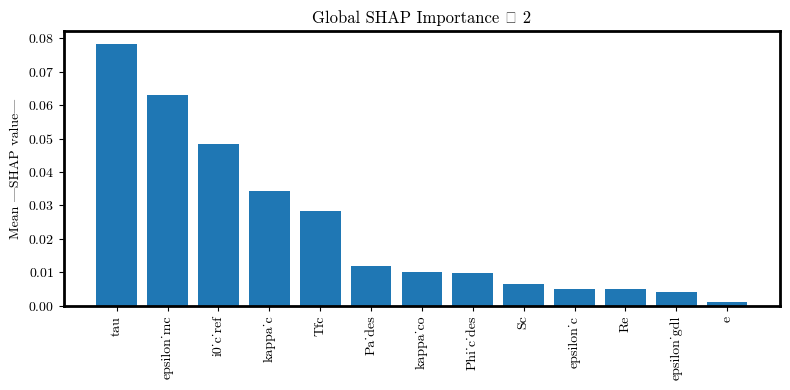

3  R² = 0.7763


/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_57097/2245681541.py:53: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  plt.tight_layout()
/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


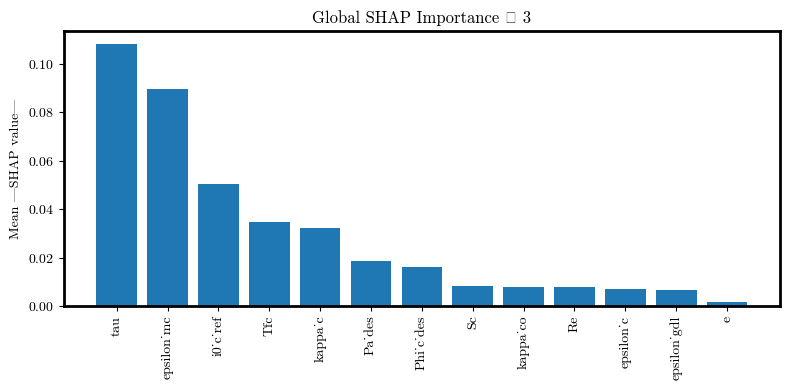

In [30]:
import shap

X = df[parameter_ranges].values    # shape (n_samples, 13)
y = np.stack(df['Ucell_regions'])        # shape (n_samples, 3)

# split once
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# scale once
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# container for results
shap_dfs = {}

for idx, region in enumerate([1,2,3]):
    # --- Train RF for this region ---
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_scaled, Y_train[:, idx])
    
    # --- Compute performance ---
    y_pred = rf.predict(X_test_scaled)
    r2 = r2_score(Y_test[:, idx], y_pred)
    print(f"{region}  R² = {r2:.4f}")
    
    # --- SHAP for this region ---
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test_scaled)  
    # shap_values shape = (n_samples, n_features)
    
    # global importances
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    df_shap = pd.DataFrame({
        'feature': parameter_ranges,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    shap_dfs[region] = df_shap
    
    # --- Optional: bar plot ---
    plt.figure(figsize=(8, 4))
    plt.bar(df_shap['feature'], df_shap['mean_abs_shap'])
    plt.xticks(rotation=90)
    plt.ylabel('Mean |SHAP value|')
    plt.title(f'Global SHAP Importance — {region}')
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import time

# === Feature sets ===
parameter_ranges = OmegaConf.load('../param_config.yaml')
top_k_features   = list(df_shap['feature'][0:5])
print(top_k_features)
# === Prepare data ===
df = all.dropna(subset=target_cols + list(parameter_ranges))
X_full = df[parameter_ranges].values
X_red  = df[top_k_features].values
y      = df[target_cols].sum(axis=1).values

# === Common setup ===
rf_params = dict(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
pipe_full = Pipeline([("scaler", StandardScaler()),
                      ("rf",     RandomForestRegressor(**rf_params))])
pipe_red  = Pipeline([("scaler", StandardScaler()),
                      ("rf",     RandomForestRegressor(**rf_params))])

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring = ["neg_root_mean_squared_error", "r2"]

# === CV evaluate both models ===
start = time.time()
res_full = cross_validate(pipe_full, X_full, y,
                          cv=cv, scoring=scoring, n_jobs=-1,
                          return_train_score=False)
time_full = time.time() - start

start = time.time()
res_red = cross_validate(pipe_red, X_red, y,
                         cv=cv, scoring=scoring, n_jobs=-1,
                         return_train_score=False)
time_red = time.time() - start

# === Aggregate ===
rmse_full = -res_full["test_neg_root_mean_squared_error"]
r2_full   = res_full["test_r2"]
rmse_red  = -res_red["test_neg_root_mean_squared_error"]
r2_red    = res_red["test_r2"]

print(f"Full (13-feat) RF CV  → RMSE = {rmse_full.mean():.3f} ± {rmse_full.std():.3f};  "
      f"R² = {r2_full.mean():.3f} ± {r2_full.std():.3f}; time = {time_full:.1f}s")
print(f"Top-k (5-feat) RF CV → RMSE = {rmse_red.mean():.3f} ± {rmse_red.std():.3f};  "
      f"R² = {r2_red.mean():.3f} ± {r2_red.std():.3f}; time = {time_red:.1f}s")


['Phi_c_des', 'Re', 'kappa_c', 'Sc', 'epsilon_c', 'kappa_co', 'epsilon_gdl']
Full (13-feat) RF CV  → RMSE = 23.986 ± 3.153;  R² = 0.715 ± 0.058; time = 82.1s
Top-k (5-feat) RF CV → RMSE = 31.775 ± 2.654;  R² = 0.501 ± 0.058; time = 61.3s


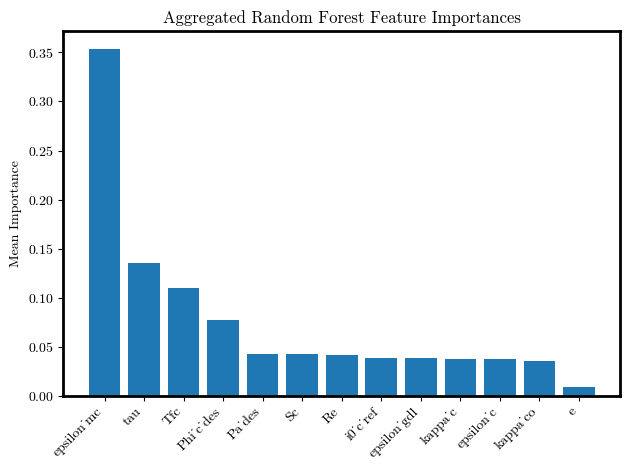

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume you have:
# - multi_rf: your fitted MultiOutputRegressor wrapper
# - parameter_ranges: list of feature names (same order as in your training X)

# Extract feature importances from each underlying estimator
all_importances = np.array([
    est.feature_importances_ 
    for est in multi_rf.estimators_
])

# Compute mean importance across all outputs
mean_importances = np.mean(all_importances, axis=0)

# Create a DataFrame for display
fi_df = pd.DataFrame({
    'feature': parameter_ranges,
    'mean_importance': mean_importances
}).sort_values('mean_importance', ascending=False)



# Plot the aggregated importances
plt.figure()
plt.bar(fi_df['feature'], fi_df['mean_importance'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Importance")
plt.title("Aggregated Random Forest Feature Importances")
plt.tight_layout()
plt.show()


In [ ]:
import shap
import numpy as np
import pandas as pd

# 1) build explainers and get shap_values
explainers = [shap.TreeExplainer(est) for est in multi_rf.estimators_]
shap_vals = np.stack([
    explainer.shap_values(X_test_scaled)
    for explainer in explainers
], axis=0)  # (n_outputs, n_samples, n_features)

# 2) global mean(|SHAP|)
global_imp = np.mean(np.abs(shap_vals), axis=(0,1))
fi_df = pd.DataFrame({
    'feature': X.columns,
    'shap_importance': global_imp
}).sort_values('shap_importance', ascending=False)

print(fi_df.head(10))


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Process SpawnProcess-20:
Traceback (most recent call last):
  File "/Users/dejvis.toptani/.pyenv/versions/3.11.5/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/dejvis.toptani/.pyenv/versions/3.11.5/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/dejvis.toptani/.pyenv/versions/3.11.5/lib/python3.11/concurrent/futures/process.py", line 244, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dejvis.toptani/.pyenv/versions/3.11.5/lib/python3.11/multiprocessing/queues.py", line 122,

BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore

In [ ]:
explainers = [shap.TreeExplainer(est) for est in multi_rf.estimators_[0]]
shap_vals = np.stack([
    explainer.shap_values(X_test_scaled)
    for explainer in explainers
], axis=0)  # (n_outputs, n_samples, n_features)

KeyboardInterrupt: 

Cluster 0 R²: 0.961


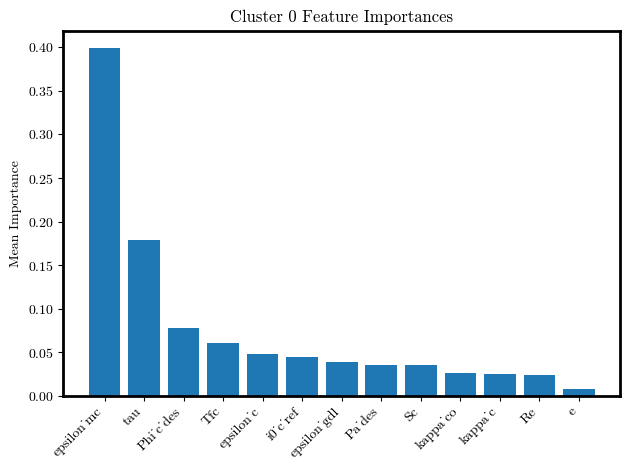

Cluster 1 R²: 0.958


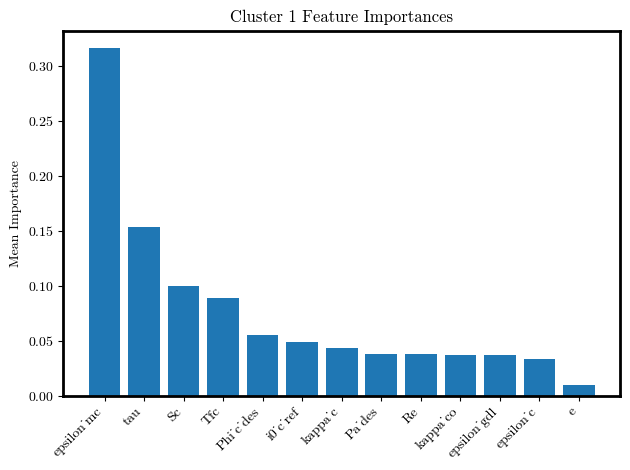

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor


# 1) Cluster into 2 groups
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# 2) For each cluster, fit a multi-output Random Forest and extract importances & R²
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    X_c, y_c = X[mask], y[mask]
    
    mor = MultiOutputRegressor(RandomForestRegressor(random_state=42))
    mor.fit(X_c, y_c)
    
    # Feature importances per target
    importances = np.vstack([est.feature_importances_ for est in mor.estimators_])
    mean_importances = importances.mean(axis=0)
    
    # Prepare DataFrame
    fi_df = pd.DataFrame({
        'feature': parameter_ranges,
        'mean_importance': mean_importances
    }).sort_values('mean_importance', ascending=False)
    
    # Display table
    
    # Compute R² (average across outputs)
    r2 = mor.score(X_c, y_c)
    print(f"Cluster {cluster_id} R²: {r2:.3f}")
    
    # Plot importances
    plt.figure()
    plt.bar(fi_df['feature'], fi_df['mean_importance'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Mean Importance")
    plt.title(f"Cluster {cluster_id} Feature Importances")
    plt.tight_layout()
    plt.show()


Random Forest for top features

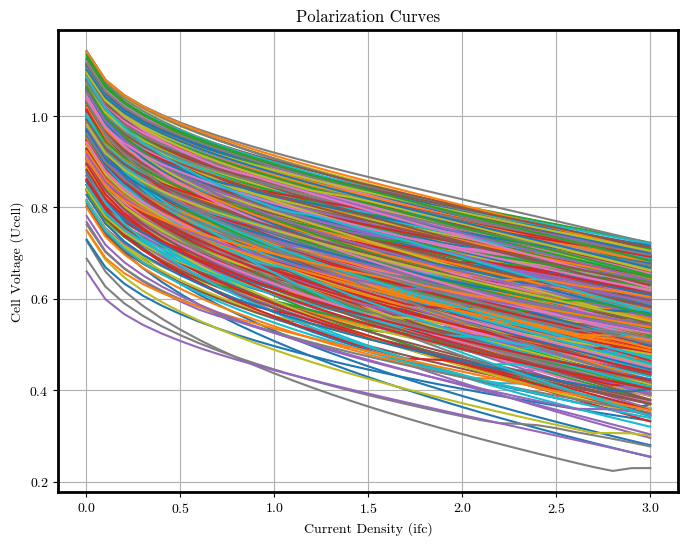

In [54]:
data = pd.read_pickle('../sampling_test/LHS_1000_5param.pkl')
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df and has 'ifc' and 'Ucell' columns
plt.figure(figsize=(8, 6))

for idx, row in data.iterrows():
    plt.plot(row['ifc'], row['Ucell'], label=f'Curve {idx}')

plt.xlabel('Current Density (ifc)')
plt.ylabel('Cell Voltage (Ucell)')
plt.title('Polarization Curves')
plt.grid(True)
plt.show()


In [55]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

parameters = ['tau', 'epsilon_mc', 'i0_c_ref', 'Tfc', 'kappa_c']
X = data[parameters]
y = data['Ucell'].apply(np.sum)

# Train a Random Forest with cross-validation
model = RandomForestRegressor(n_estimators=100, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=5)

# Evaluate
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Cross-Validated MSE: {mse:.4f}")
print(f"Cross-Validated R²: {r2:.4f}")

Cross-Validated MSE: 0.2219
Cross-Validated R²: 0.9605


 98%|===================| 983/1000 [00:15<00:00]        

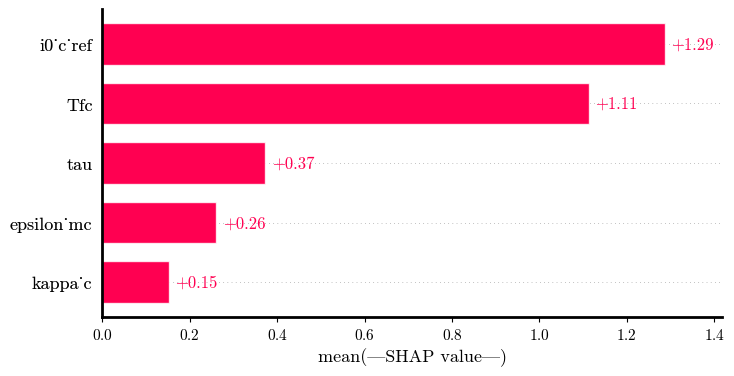

In [56]:
import shap
from sklearn.ensemble import RandomForestRegressor

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Compute SHAP values
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# Plot global importance
shap.plots.bar(shap_values)
